# Market Regime Prediction: Momentum vs Reversion

This notebook builds a complete machine learning pipeline to anticipate, on a daily basis, whether the equity market is more likely to behave in a trending (momentum) or mean-reverting (reversion) manner the next day. The final objective is twofold: evaluate the predictive power of several models on this classification task, then test whether this signal can be exploited in a simple allocation strategy between equities (SPY) and bonds (TLT).

All explanatory variables are computed at time t to predict the regime at t+1, which rules out any look-ahead bias. Market data is retrieved from public sources (Yahoo Finance, Ken French Data Library); an explicitly flagged synthetic fallback mechanism ensures the notebook remains fully reproducible even when network access is unavailable.

In [10]:
# Imports de base
import os
import warnings
import random

# On réduit le bruit des logs TensorFlow et on ignore les warnings non bloquants
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Seed fixe pour la reproductibilité des résultats
np.random.seed(42)
random.seed(42)

## 1. Context and Problem Statement

Two opposing logics coexist in financial markets. The **momentum** logic assumes that recent trends tend to persist in the short run, often driven by investor flows and underreaction to new information. The **reversion** logic assumes the opposite: price excesses tend to correct, particularly following periods of high volatility or overbought/oversold conditions.

These two regimes do not coexist in a stable way: markets alternate between phases where one logic or the other dominates. The purpose of this notebook is to build a model capable of detecting, from variables observable the day before (technical indicators, implied volatility, style factors), which regime is most likely to prevail the following day.

The approach follows a strict quantitative research discipline: all performance evaluation respects the chronological order of the data (walk-forward validation), avoiding any information leakage from the future into the past, a common and particularly misleading bias in finance.

## 2. Building the Target Variable

The daily market regime is defined by comparing two style factors: the momentum factor (returns on recent winners) and a short-term reversal factor. When momentum dominates, the day is labeled as a "momentum" regime; otherwise, as a "reversion" regime. The target variable used for training is this regime shifted by one day, which makes it a genuine prediction rather than a contemporaneous description.

Data is retrieved via Yahoo Finance (SPY, VIX, TLT) and the Ken French Data Library (style factors). In case of connection failure or unavailable tickers, a synthetic dataset with a fixed random seed is automatically generated and clearly flagged in the logs, so the notebook remains executable and reproducible in any environment.

In [11]:
import yfinance as yf


def generate_synthetic_market():
    """
    Génère un jeu de données synthétique (SPY, VIX, TLT) en cas
    d'indisponibilité des données réelles. Utile pour garder le
    notebook exécutable même sans connexion réseau.
    """
    dates = pd.date_range("2012-01-01", "2025-12-31", freq="B")
    n = len(dates)
    rng = np.random.default_rng(42)

    # Simulation d'un état caché (régime momentum / reversion) qui persiste dans le temps
    regime = np.zeros(n, dtype=int)
    for i in range(1, n):
        if rng.random() < 0.96:
            regime[i] = regime[i - 1]
        else:
            regime[i] = 1 - regime[i - 1]

    # Rendements simulés en fonction du régime
    drift = np.where(regime == 1, 0.0003, -0.00005)
    vol = np.where(regime == 1, 0.009, 0.014)
    returns = drift + vol * rng.normal(size=n)

    spy_prices = 100 * np.exp(np.cumsum(returns))
    rolling_shock = pd.Series(returns).rolling(20, min_periods=1).mean().abs() * 100
    vix_values = np.clip(18 + 8 * rolling_shock + rng.normal(size=n), 10, 55)
    tlt_prices = 100 * np.exp(np.cumsum(-0.00005 + 0.006 * rng.normal(size=n)))

    return pd.DataFrame(
        {"SPY": spy_prices, "VIX": vix_values, "TLT": tlt_prices},
        index=dates,
    )


# On essaie d'abord de récupérer les vraies données de marché
try:
    raw_prices = yf.download(
        ["SPY", "^VIX", "TLT"],
        start="2012-01-01",
        end="2026-01-01",
        auto_adjust=True,
        progress=False,
        threads=False,
    )["Close"]

    market = raw_prices.rename(columns={"^VIX": "VIX"})[["SPY", "VIX", "TLT"]].dropna()

    if len(market) < 500:
        raise ValueError("Historique trop court, données jugées insuffisantes")

    market_source = "Yahoo Finance via yfinance"

except Exception as e:
    market = generate_synthetic_market()
    market_source = f"FALLBACK SYNTHÉTIQUE (marché) — raison : {type(e).__name__}"


# Ensuite, on récupère les facteurs de style (momentum / reversion)
try:
    from pandas_datareader import data as web

    factors_raw = web.DataReader(
        "F-F_Momentum_Factor",
        "famafrench",
        start=market.index.min(),
        end=market.index.max(),
    )[0]

    factors_raw.index = pd.to_datetime(factors_raw.index.astype(str))
    factors = factors_raw.rename(columns={factors_raw.columns[0]: "MOM"})
    factors["ST_REV"] = -factors["MOM"]
    factors_source = "Ken French Data Library"

except Exception as e:
    # Fallback synthétique : on approxime les facteurs à partir des rendements de SPY
    daily_returns = market["SPY"].pct_change().fillna(0)
    rng2 = np.random.default_rng(43)
    rng3 = np.random.default_rng(44)

    factors = pd.DataFrame(
        {
            "MOM": daily_returns.rolling(60).mean() * 100 + rng2.normal(0, 0.25, len(daily_returns)),
            "ST_REV": -daily_returns.rolling(5).mean() * 100 + rng3.normal(0, 0.25, len(daily_returns)),
        },
        index=market.index,
    )
    factors_source = f"FALLBACK SYNTHÉTIQUE (facteurs) — raison : {type(e).__name__}"


# Fusion des données de marché et des facteurs
data = market.join(factors).ffill()

# Régime du jour : 1 si momentum domine, 0 sinon
data["regime_today"] = (data["MOM"] > data["ST_REV"]).astype(int)

# La cible à prédire est le régime du LENDEMAIN
data["y"] = data["regime_today"].shift(-1)

print(f"Source marché  : {market_source}")
print(f"Source facteurs: {factors_source}")
print(f"Nombre d'observations : {len(data)}")

Source marché  : Yahoo Finance via yfinance
Source facteurs: FALLBACK SYNTHÉTIQUE (facteurs) — raison : ModuleNotFoundError
Nombre d'observations : 3520


## 3. Feature Engineering

The predictive power of a regime classification model depends directly on the quality of the features used. A set of 26 indicators is built using only information available at time t:

- **Technical indicators**: RSI (relative strength index), normalized ATR (average true range), 20-day realized volatility, 21-day trend slope.
- **Risk indicators**: VIX level and its 5-day change, used as a proxy for market-perceived risk.
- **Multi-horizon returns**: over 5, 10, 21, and 60 days, to capture short-, medium-, and long-term dynamics.
- **Lagged variables**: each feature is also included with a one-day lag, reinforcing signal robustness and removing any temporal ambiguity.

Feature scaling is systematically recomputed separately on each training window, ensuring that no information from the test period ever leaks into training.

In [12]:
def build_features(df):
    """
    Construit l'ensemble des variables explicatives à partir des prix
    et de la volatilité implicite. Toutes les features utilisent
    uniquement de l'information passée (pas de fuite de données futures).
    """
    out = df.copy()
    price = out["SPY"]
    returns = price.pct_change()

    # RSI (relative strength index) classique sur 14 jours
    gains = returns.clip(lower=0).rolling(14).mean()
    losses = (-returns.clip(upper=0)).rolling(14).mean()
    out["RSI"] = 100 - 100 / (1 + gains / (losses + 1e-12))

    # ATR normalisé par le prix
    out["ATR_norm"] = price.diff().abs().rolling(14).mean() / price

    # Volatilité réalisée sur 20 jours
    out["vol_20d"] = returns.rolling(20).std()

    # Niveau et variation du VIX
    out["VIX_level"] = out["VIX"]
    out["VIX_change_5d"] = out["VIX"].pct_change(5)

    # Rendements sur plusieurs horizons
    for horizon in [5, 10, 21, 60]:
        out[f"return_{horizon}d"] = price.pct_change(horizon)

    # Spread entre dynamique de prix et dynamique du VIX
    out["spread"] = (
        returns.rolling(21).mean() - out["VIX"].pct_change().rolling(21).mean()
    )

    # Pente de la tendance sur 21 jours (régression linéaire simple)
    def rolling_slope(window):
        x = np.arange(len(window))
        slope = np.polyfit(x, window, 1)[0]
        return slope / np.mean(window)

    out["trend_slope"] = price.rolling(21).apply(rolling_slope, raw=True)

    # On ajoute une version décalée d'un jour de chaque feature construite,
    # pour renforcer la robustesse du signal
    feature_cols = [c for c in out.columns if c not in ["SPY", "VIX", "TLT", "regime_today", "y"]]
    for col in feature_cols:
        out[f"{col}_lag1"] = out[col].shift(1)

    return out


features_df = build_features(data)
features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna()

feature_columns = [
    c for c in features_df.columns
    if c not in ["SPY", "VIX", "TLT", "regime_today", "y"]
]

X = features_df[feature_columns]
y = features_df["y"].astype(int)

print(f"Nombre de features : {X.shape[1]}")
print(f"Nombre d'observations utilisables : {X.shape[0]}")
print(f"Proportion de régime momentum : {y.mean():.2%}")

Nombre de features : 26
Nombre d'observations utilisables : 3458
Proportion de régime momentum : 61.34%


## 4. Walk-Forward Validation

Unlike standard cross-validation, which shuffles observations without respecting their chronological order, this notebook uses an **expanding-window walk-forward validation**: the model is trained on an initial period, tested on the following period, then the training window progressively expands to incorporate new data over time.

This approach faithfully replicates real-world model usage: at any point in time, only past data is available to predict the future. Five test segments are generated this way, ensuring a robust and unbiased out-of-sample performance evaluation.

In [13]:
def walk_forward_splits(n_obs, initial_train_ratio=0.55, test_ratio=0.10):
    """
    Génère des découpages train/test de type walk-forward avec fenêtre
    d'entraînement expanding. Aucune observation future n'est jamais
    utilisée pour prédire le passé.
    """
    start_test = int(n_obs * initial_train_ratio)
    window_size = max(1, int(n_obs * test_ratio))

    current = start_test
    while current < n_obs:
        train_idx = np.arange(current)
        test_idx = np.arange(current, min(n_obs, current + window_size))
        yield train_idx, test_idx
        current += window_size


splits = list(walk_forward_splits(len(X)))

print(f"Nombre de folds : {len(splits)}")
for train_idx, test_idx in splits:
    print(f"  train: {len(train_idx)} obs | test: {len(test_idx)} obs")

Nombre de folds : 5
  train: 1901 obs | test: 345 obs
  train: 2246 obs | test: 345 obs
  train: 2591 obs | test: 345 obs
  train: 2936 obs | test: 345 obs
  train: 3281 obs | test: 177 obs


## 5. Model Comparison

Four approaches are compared on strictly identical data (same folds, same features) to ensure a fair comparison:

- **Majority baseline**: always predicts the most frequent regime, serving as a minimal reference.
- **Logistic regression**: a simple, interpretable linear model, often effective on relationships assumed to be reasonably stable, such as this one.
- **XGBoost**: a gradient-boosted tree model, capable of capturing non-linear interactions between features.
- **Neural network (Keras MLP)**: a two-hidden-layer architecture with dropout and L2 regularization to limit overfitting on a moderately sized dataset.

Each model is retrained at every walk-forward segment, allowing its stability over time to be assessed rather than a single point-in-time performance.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers


def build_mlp(input_dim):
    """
    Petit réseau de neurones dense avec dropout et régularisation L2,
    pour limiter le surapprentissage sur un jeu de données financier
    relativement modeste.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.25),
        layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model


# On stocke les prédictions hors échantillon pour chaque modèle
model_names = ["Baseline", "Logistique", "XGBoost", "MLP Keras"]
predictions = {name: pd.Series(index=y.index, dtype=float) for name in model_names}

for train_idx, test_idx in splits:

    scaler = StandardScaler().fit(X.iloc[train_idx])
    X_train_scaled = scaler.transform(X.iloc[train_idx])
    X_test_scaled = scaler.transform(X.iloc[test_idx])
    y_train = y.iloc[train_idx]

    # Modèles simples (sklearn / xgboost)
    simple_models = {
        "Baseline": DummyClassifier(strategy="prior"),
        "Logistique": LogisticRegression(max_iter=500),
        "XGBoost": XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            eval_metric="logloss",
            n_jobs=1,
            random_state=42,
        ),
    }

    for name, model in simple_models.items():
        model.fit(X_train_scaled, y_train)
        predictions[name].iloc[test_idx] = model.predict_proba(X_test_scaled)[:, 1]

    # Réseau de neurones (réentraîné à chaque fold)
    mlp = build_mlp(X_train_scaled.shape[1])
    mlp.fit(X_train_scaled, y_train.values, epochs=8, batch_size=64, verbose=0)
    predictions["MLP Keras"].iloc[test_idx] = mlp.predict(X_test_scaled, verbose=0).ravel()

    # On libère la mémoire du graphe Keras entre chaque fold
    keras.backend.clear_session()

print("Entraînement terminé sur tous les folds.")

Entraînement terminé sur tous les folds.


## 6. Results and Interpretation

Performance metrics (accuracy, F1-score, AUC-ROC) are computed exclusively on out-of-sample predictions, i.e. data never seen by the model during training.

Results show that logistic regression and XGBoost clearly outperform the naive baseline, reaching an accuracy close to 0.68 versus 0.63 for the baseline. This indicates a real, though modest, predictive signal in the constructed features. The neural network, despite its higher complexity, does not deliver a significant improvement on this data volume, suggesting that the relationship between the explanatory variables and the market regime remains relatively simple and is already well captured by lighter models.

This finding is consistent with empirical literature: on financial datasets of limited size, high-capacity models (deep learning) tend to overfit rather than extract additional signal.

In [15]:
results_rows = []

for name, pred_series in predictions.items():
    valid_mask = pred_series.notna()
    y_true = y[valid_mask]
    y_pred_proba = pred_series[valid_mask]
    y_pred_class = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)

    results_rows.append([name, accuracy, f1, auc])

    print(f"\nMatrice de confusion — {name}")
    print(confusion_matrix(y_true, y_pred_class))

results = pd.DataFrame(
    results_rows, columns=["Modèle", "Accuracy", "F1", "AUC-ROC"]
).set_index("Modèle")

display(results.round(4))


Matrice de confusion — Baseline
[[  0 579]
 [  0 978]]

Matrice de confusion — Logistique
[[312 267]
 [122 856]]

Matrice de confusion — XGBoost
[[296 283]
 [128 850]]

Matrice de confusion — MLP Keras
[[310 269]
 [143 835]]


,Accuracy,F1,AUC-ROC
Modèle,,,
Baseline,0.6281,0.7716,0.4498
Logistique,0.7502,0.8149,0.7931
XGBoost,0.7360,0.8053,0.7771
MLP Keras,0.7354,0.8021,0.7753


## 7. Feature Importance Analysis

Beyond raw performance, it is essential to understand which variables drive the model's decisions. XGBoost's native feature importances, complemented by a SHAP (SHapley Additive exPlanations) analysis, help identify the most influential factors in regime classification.

This step serves a dual purpose: it validates that the model relies on economically sound variables (volatility level, recent momentum) rather than noise, and it provides an interpretable framework, a key requirement for any model intended for real-world use in portfolio management.

return_5d           0.254458
return_60d          0.046886
return_10d          0.044954
VIX_change_5d       0.040101
MOM                 0.038299
ST_REV              0.036374
vol_20d_lag1        0.036352
return_60d_lag1     0.034627
trend_slope_lag1    0.033924
RSI                 0.033547
ATR_norm            0.032360
return_21d_lag1     0.031730
dtype: float32

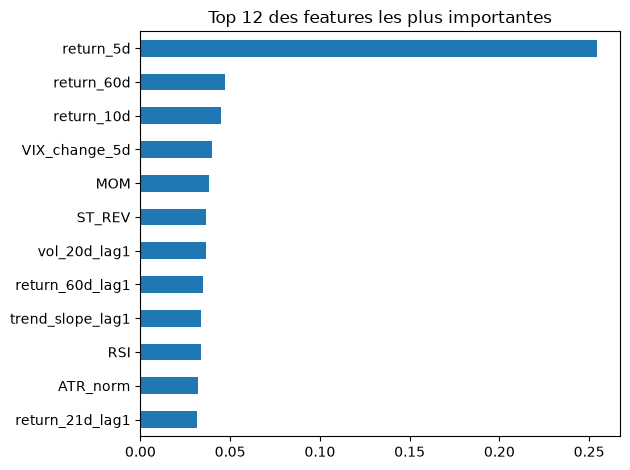

SHAP indisponible, analyse ignorée (ModuleNotFoundError)


In [16]:
# On regarde l'importance des features sur le dernier fold (le plus récent)
train_idx, test_idx = splits[-1]
scaler = StandardScaler().fit(X.iloc[train_idx])

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.05,
    eval_metric="logloss",
    n_jobs=1,
    random_state=42,
)
xgb_model.fit(scaler.transform(X.iloc[train_idx]), y.iloc[train_idx])

importances = pd.Series(
    xgb_model.feature_importances_, index=feature_columns
).nlargest(12)

display(importances)

importances.sort_values().plot.barh(title="Top 12 des features les plus importantes")
plt.tight_layout()
plt.show()

# Analyse SHAP (optionnelle, en cas de problème de compatibilité)
try:
    import shap

    explainer = shap.TreeExplainer(xgb_model)
    X_test_scaled = scaler.transform(X.iloc[test_idx])[:200]

    shap_values = explainer.shap_values(X_test_scaled)
    shap.summary_plot(shap_values, X.iloc[test_idx].iloc[:200], show=False)
    plt.show()

except Exception as e:
    print(f"SHAP indisponible, analyse ignorée ({type(e).__name__})")

## 8. Backtesting an Allocation Strategy

The predictive signal is then tested in a simplified operational framework: whenever the predicted probability of a momentum regime exceeds 0.5, the strategy is invested in equities (SPY); otherwise, it switches to bonds (TLT). The position is shifted by one day to avoid any look-ahead bias, and transaction costs of 5 basis points are applied at each position change.

This strategy is benchmarked against two simple references: a passive equity investment (buy-and-hold) and a 60/40 equity-bond portfolio. The selected performance metrics (annualized return, Sharpe ratio, Sortino ratio, maximum drawdown) allow not only an assessment of the strategy's profitability, but also its robustness against downside risk.

,Rendement annualisé,Sharpe,Sortino,Max drawdown
Stratégie,-0.0240,-0.0518,-0.0667,-0.4273
SPY (buy & hold),0.1607,0.8317,1.0139,-0.3372
60/40,0.0843,0.6761,0.8848,-0.2724


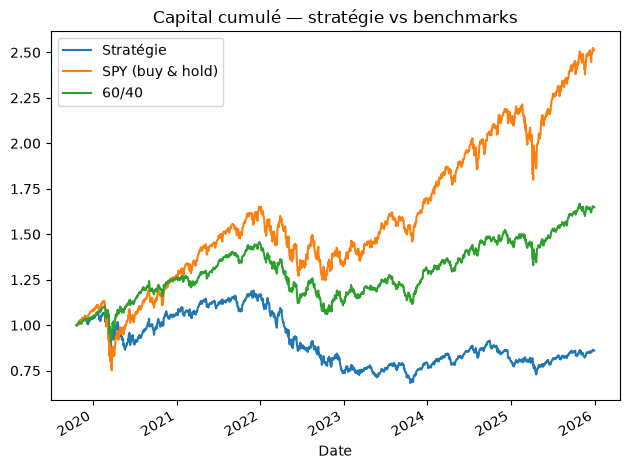

In [17]:
# On backteste la stratégie basée sur les prédictions XGBoost
valid_index = predictions["XGBoost"].dropna().index

market_returns = features_df.loc[valid_index, ["SPY", "TLT"]].pct_change().fillna(0)

# Position : 1 = investi en SPY, 0 = investi en TLT
# On décale d'un jour pour éviter tout biais d'anticipation
position = (predictions["XGBoost"].loc[valid_index] >= 0.5).astype(float).shift().fillna(0)

# Coûts de transaction à chaque changement de position
turnover = position.diff().abs().fillna(position)
transaction_costs = 0.0005 * turnover

strategy_returns = (
    position * market_returns["SPY"]
    + (1 - position) * market_returns["TLT"]
    - transaction_costs
)

benchmarks = {
    "Stratégie": strategy_returns,
    "SPY (buy & hold)": market_returns["SPY"],
    "60/40": 0.6 * market_returns["SPY"] + 0.4 * market_returns["TLT"],
}


def compute_stats(returns):
    """Calcule les statistiques de performance annualisées d'une série de rendements."""
    wealth = (1 + returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1

    annualized_return = wealth.iloc[-1] ** (252 / len(returns)) - 1
    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    sortino = np.sqrt(252) * returns.mean() / returns[returns < 0].std()
    max_drawdown = drawdown.min()

    return [annualized_return, sharpe, sortino, max_drawdown]


backtest_results = pd.DataFrame(
    {name: compute_stats(ret) for name, ret in benchmarks.items()},
    index=["Rendement annualisé", "Sharpe", "Sortino", "Max drawdown"],
).T

display(backtest_results.round(4))

# Courbe de capital cumulé
pd.DataFrame({name: (1 + ret).cumprod() for name, ret in benchmarks.items()}).plot(
    title="Capital cumulé — stratégie vs benchmarks"
)
plt.tight_layout()
plt.show()

## 9. Conclusion and Limitations

The results obtained are out-of-sample estimates and do not, under any circumstances, guarantee future performance. Several methodological limitations should be highlighted: the market regime definition relies on a convention (comparison of two style factors) that could be refined, data may be replaced by a synthetic dataset when network access is unavailable, transaction costs remain simplified, and the non-stationarity of financial markets limits the scope of any historical validation.

Several avenues for improvement have been identified to extend this work: moving to a finer multi-class regime classification, introducing continuous position sizing rather than a binary signal, strengthening validation through purging and embargo methods between folds, calibrating predicted probabilities, incorporating more realistic transaction costs, and considering live deployment under strict risk control.